<h1>E-Commerce Purchase Prediction</h1>

In [1]:
# all imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew
from sklearn.linear_model import LinearRegression as LinReg
from sklearn.ensemble import RandomForestRegressor as RanForReg
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import root_mean_squared_error as rmse, mean_absolute_error as mae, r2_score

print("All imports done")

All imports done


In [2]:
# loading the dataset
purchase_data = pd.read_csv("ecommerce_purchase.csv")

purchase_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5055 entries, 0 to 5054
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   OrderID               5055 non-null   str    
 1   Customer_Age          4928 non-null   float64
 2   Membership_Years      4905 non-null   float64
 3   Items_In_Cart         5055 non-null   int64  
 4   Discount_Pct          4954 non-null   str    
 5   Delivery_Distance_KM  4880 non-null   float64
 6   Product_Category      5055 non-null   str    
 7   Payment_Method        4953 non-null   str    
 8   Is_Premium_Member     5055 non-null   str    
 9   Season                5055 non-null   str    
 10  Day_Of_Week           5055 non-null   str    
 11  Transaction_Amount    5030 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 474.0 KB


In [3]:
# shape, data types, missing values
print(f"Shape of the dataset: {purchase_data.shape}\n\nData Types: \n{purchase_data.dtypes}\n\nNull Values: \n{purchase_data.isnull().sum()}")

# we can see there are over hundreds of missing values in some columns and 25 missing values in the target variable, we need to drop them first
purchase_data = purchase_data.dropna(subset=["Transaction_Amount"])
print(f"\nNow there are no missing values in target variable: \n{purchase_data.isnull().sum()}")

Shape of the dataset: (5055, 12)

Data Types: 
OrderID                     str
Customer_Age            float64
Membership_Years        float64
Items_In_Cart             int64
Discount_Pct                str
Delivery_Distance_KM    float64
Product_Category            str
Payment_Method              str
Is_Premium_Member           str
Season                      str
Day_Of_Week                 str
Transaction_Amount      float64
dtype: object

Null Values: 
OrderID                   0
Customer_Age            127
Membership_Years        150
Items_In_Cart             0
Discount_Pct            101
Delivery_Distance_KM    175
Product_Category          0
Payment_Method          102
Is_Premium_Member         0
Season                    0
Day_Of_Week               0
Transaction_Amount       25
dtype: int64

Now there are no missing values in target variable: 
OrderID                   0
Customer_Age            127
Membership_Years        150
Items_In_Cart             0
Discount_Pct            1

In [4]:
# EDA Check Payment_Method and Is_Premium_Member for inconsistent capitalisation. List all unique values found before cleaning
unique_payment_methods = purchase_data["Payment_Method"].unique()
unique_premium_members = purchase_data["Is_Premium_Member"].unique()

print(f"Unique values for payment methods: {unique_payment_methods}")
print(f"Unique values for is permium member: {unique_premium_members}")


Unique values for payment methods: <StringArray>
[         'UPI',   'Debit Card',  'Credit Card',   'DEBIT CARD',
  'CREDIT CARD',       'Wallet',            nan,  'credit card',
   'debit card', ' Debit card ',       'WALLET', ' Credit card',
     ' Wallet ',         ' UPI',          'upi',       'wallet',
          'Upi']
Length: 17, dtype: str
Unique values for is permium member: <StringArray>
['no', 'No', 'Yes', 'yes', ' No', 'Y', 'NO', 'N', 'YES', ' Yes']
Length: 10, dtype: str


In [5]:
# to clean them, we need to convert all of them to lowercase and remove leading and trailing whitespaces

purchase_data["Payment_Method"] = purchase_data["Payment_Method"].str.lower().str.strip()
purchase_data["Is_Premium_Member"] = purchase_data["Is_Premium_Member"].str.lower().str.strip()

# to fill the NaN values in payment method, we fill them with mode as it is a categorical column
payment_mode = purchase_data["Payment_Method"].mode()[0] # taking the 0th index as .mode() returns a series
purchase_data["Payment_Method"] = purchase_data["Payment_Method"].fillna(payment_mode)

# we can also change y and n to yes and no, so we only have 2 unique values
purchase_data["Is_Premium_Member"] = purchase_data["Is_Premium_Member"].replace({"y":"yes", "n":"no"})

# now the unique values are
print(f"Unique values for payment methods after cleaning: \n{purchase_data['Payment_Method'].unique()}")
print(f"Unique values for is permium member after cleaning: \n{purchase_data['Is_Premium_Member'].unique()}")

Unique values for payment methods after cleaning: 
<StringArray>
['upi', 'debit card', 'credit card', 'wallet']
Length: 4, dtype: str
Unique values for is permium member after cleaning: 
<StringArray>
['no', 'yes']
Length: 2, dtype: str


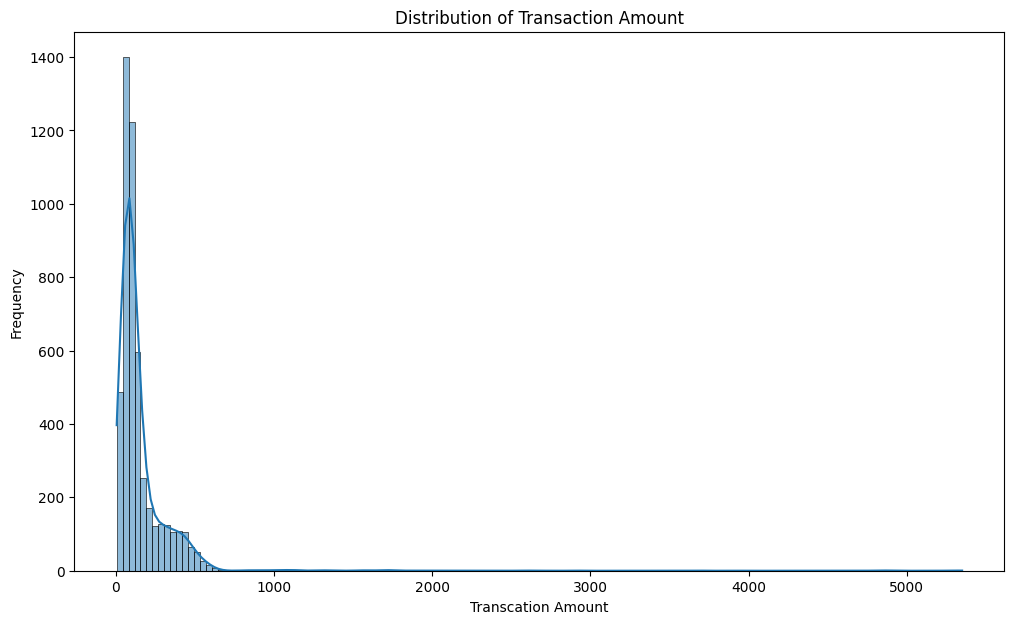

Skewness is: 12.09


In [6]:
# Plot the distribution of Transaction_Amount. Is it normally distributed or skewed? Discuss implications for regression

plt.figure(figsize=(12,7))
sns.histplot(purchase_data["Transaction_Amount"], kde=True)
plt.ylabel("Frequency")
plt.xlabel("Transcation Amount")
plt.title("Distribution of Transaction Amount")
plt.show()

# to check for skewness
skew_value = skew(purchase_data["Transaction_Amount"])
print(f"Skewness is: {skew_value:.2f}")

# as we can see the skew value is 12, so the distribution is highly right skewed

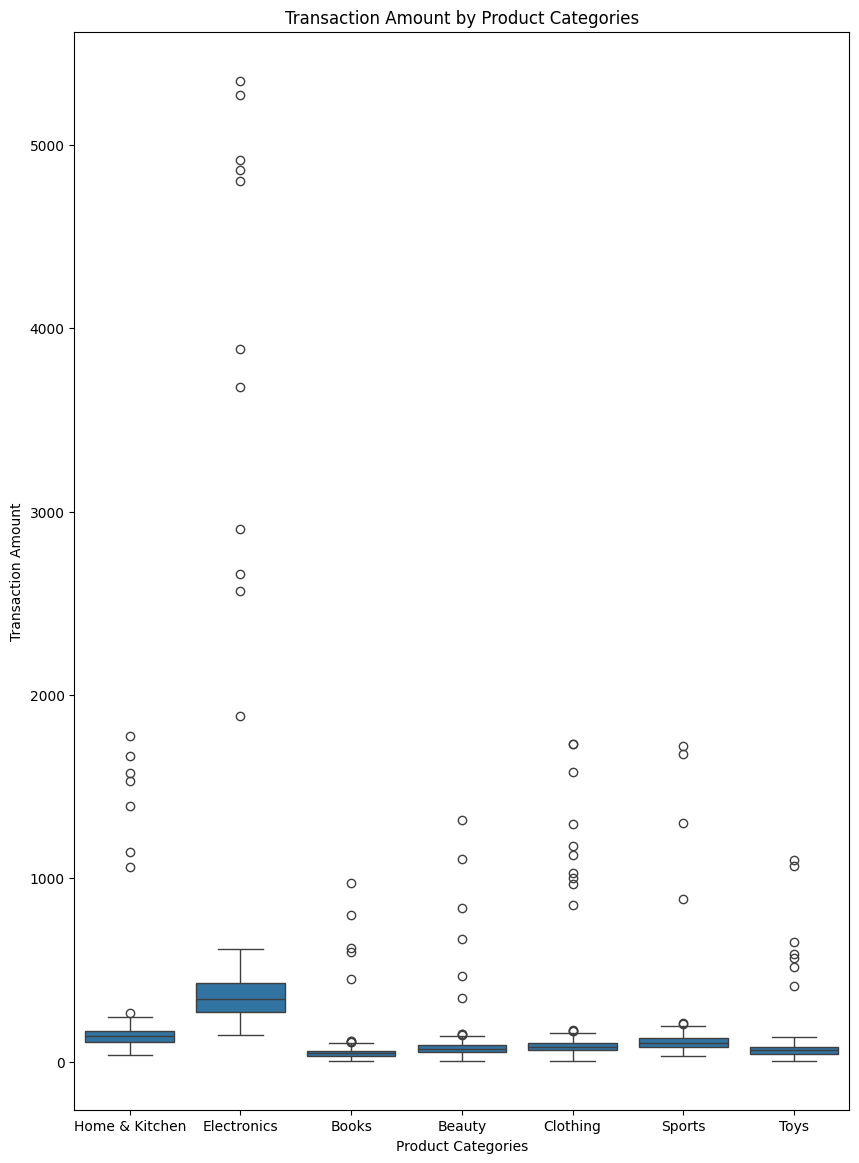

In [7]:
# box plot to see the outliers

plt.figure(figsize=(10,14))
sns.boxplot(x=purchase_data["Product_Category"], y=purchase_data["Transaction_Amount"])
plt.title("Transaction Amount by Product Categories")
plt.ylabel("Transaction Amount")
plt.xlabel("Product Categories")
plt.show()

# we can see there are many extreme outliers, most of them belonging to Electronics category

229    -12.0
334    -29.5
467    -11.8
643    -15.0
660     -3.4
881     -6.0
908     -3.9
965     -5.0
1043    -2.9
1135    -4.6
1187    -0.3
1256    -6.5
1508   -11.7
1734    -1.7
1768    -4.0
1996   -20.4
2047    -3.5
2143   -17.7
2452    -7.9
2620    -4.8
2695    -1.3
2808    -6.7
2827    -0.2
2963    -0.3
2971    -2.8
2975    -9.3
3211    -2.1
3317    -8.9
3415    -5.6
3595    -0.2
3650    -1.8
3823    -3.0
3840   -27.9
4058    -1.2
4073    -5.2
4135   -15.5
4156   -46.3
4216   -11.0
4222    -3.5
4349    -5.5
4364   -41.3
4499    -5.4
4678    -4.1
4760    -1.8
4765    -4.0
Name: Delivery_Distance_KM, dtype: float64

Total null values: 175


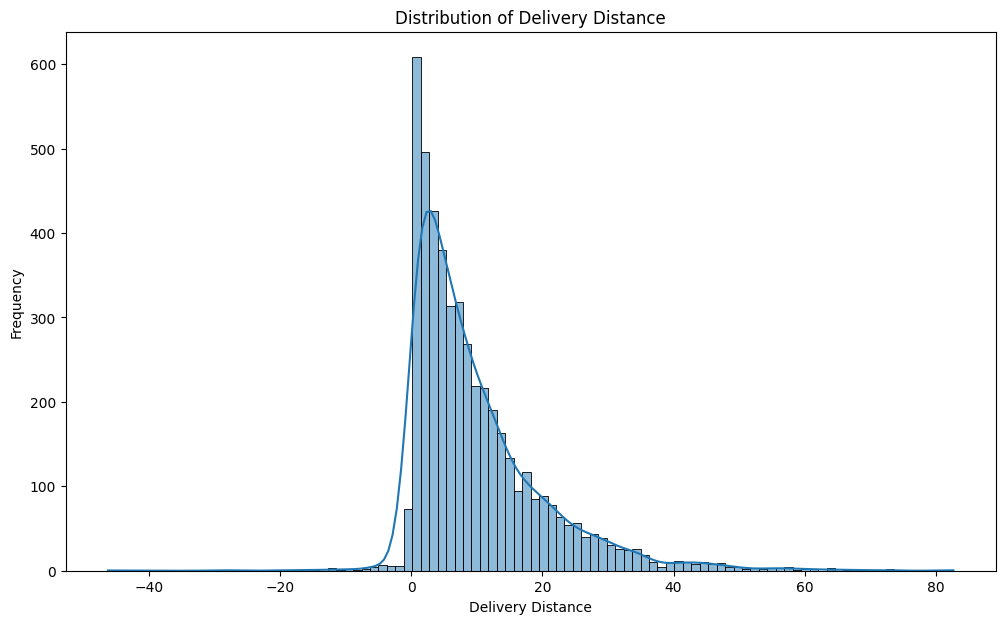

In [8]:
 # Identify physically implausible values in Delivery_Distance_KM (e.g. negative values). How many rows are affected?

# first we check the negative values in delivery distance
negative_values = purchase_data[purchase_data["Delivery_Distance_KM"]<0]
print(negative_values.Delivery_Distance_KM)

# nw we check how many have 0 value or null
null_values_count = purchase_data['Delivery_Distance_KM'].isnull().sum()
print(f"\nTotal null values: {null_values_count}")

# checking if the column is skewed or not
plt.figure(figsize=(12,7))
sns.histplot(purchase_data["Delivery_Distance_KM"], kde=True)
plt.ylabel("Frequency")
plt.xlabel("Delivery Distance")
plt.title("Distribution of Delivery Distance")
plt.show()
# it is not skewed

In [9]:
# we can just flip the sign of negatives
only_neg = purchase_data["Delivery_Distance_KM"] < 0   # creates a series of True/False based on whether delivery distance is negative or not
purchase_data.loc[only_neg, "Delivery_Distance_KM"] = purchase_data.loc[only_neg, "Delivery_Distance_KM"] * -1

# and for the NaN values, we can replace it with mean, as it is not skewed
del_dist_mean = purchase_data["Delivery_Distance_KM"].mean()
purchase_data["Delivery_Distance_KM"] = purchase_data["Delivery_Distance_KM"].fillna(del_dist_mean)

# we have no NaN values in Delivery Distance
print(purchase_data["Delivery_Distance_KM"].info())

# check for negative values
negative_values = purchase_data[purchase_data["Delivery_Distance_KM"]<0]
print("\n",negative_values.Delivery_Distance_KM)

<class 'pandas.Series'>
Index: 5030 entries, 0 to 5054
Series name: Delivery_Distance_KM
Non-Null Count  Dtype  
--------------  -----  
5030 non-null   float64
dtypes: float64(1)
memory usage: 78.6 KB
None

 Series([], Name: Delivery_Distance_KM, dtype: float64)


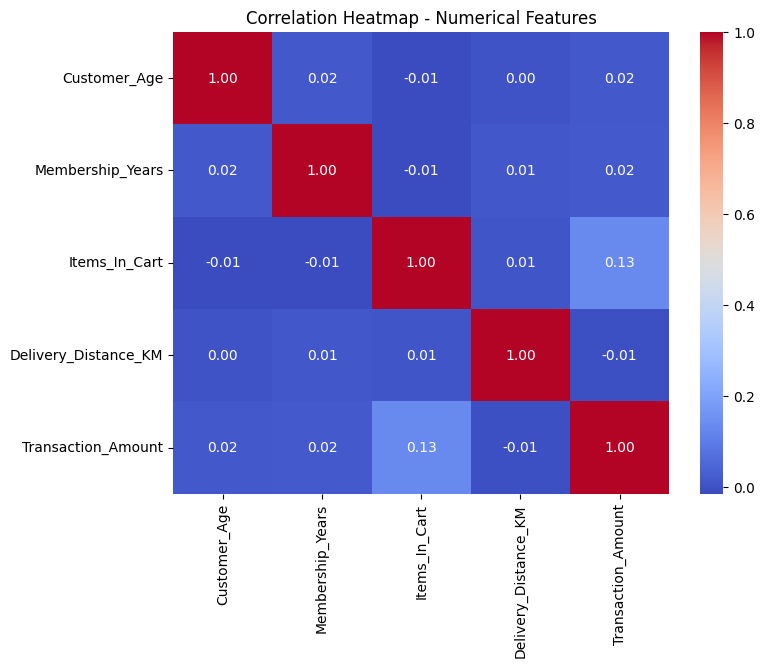

In [10]:
# Compute and plot a correlation heatmap for all numerical features. Which feature is most correlated with Transaction_Amount

numeric_cols = purchase_data.select_dtypes(include=[np.number])
corr = numeric_cols.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Numerical Features')
plt.show()


In [11]:
# Standardise Payment_Method and Is_Premium_Member to Title Case / consistent format. Verify with unique value counts

# Done on cell 5
# all data items converted to lowercase and spaces trimmed
# nan values replaced with mode
# y and n values for is_premium_member changed to yes and no

# the unique values are
print(f"Unique values for payment methods: \n{purchase_data['Payment_Method'].unique()}")
print(f"\nUnique values for is permium member: \n{purchase_data['Is_Premium_Member'].unique()}")

Unique values for payment methods: 
<StringArray>
['upi', 'debit card', 'credit card', 'wallet']
Length: 4, dtype: str

Unique values for is permium member: 
<StringArray>
['no', 'yes']
Length: 2, dtype: str


In [12]:
# Replace out-of-range values (e.g. negative Delivery_Distance_KM) with NaN using domain knowledge.

# did in cell 9
# flipped the negative values
# assigned mean to nan values

In [13]:
# Impute missing values: median for skewed columns, mean for normal columns, mode for categorical columns.

# remaining numerical columns are 
# customer age, membership_years, items in cart and discount pct 

# items in cart has no missing values

# for customer age
# we can impute with mean value
cust_age_mean = purchase_data["Customer_Age"].mean()
purchase_data["Customer_Age"] = purchase_data["Customer_Age"].fillna(cust_age_mean)

# for membership years
# same, fill with mean values
mem_years_mean = purchase_data["Membership_Years"].mean()
purchase_data["Membership_Years"] = purchase_data["Membership_Years"].fillna(mem_years_mean)
# print(purchase_data["Membership_Years"].isnull().sum())

# for items discount pct
# we need to stip the %
# and fill with mean
purchase_data["Discount_Pct"] = purchase_data["Discount_Pct"].str.strip().str.replace("%","") # stripped and removed %
purchase_data["Discount_Pct"] = pd.to_numeric(purchase_data["Discount_Pct"])  # changed data type of column to numeric
dis_pct_mean = purchase_data["Discount_Pct"].mean()
purchase_data["Discount_Pct"] = purchase_data["Discount_Pct"].fillna(dis_pct_mean)

# now all columns are cleaned and transformed
purchase_data.info()

<class 'pandas.DataFrame'>
Index: 5030 entries, 0 to 5054
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   OrderID               5030 non-null   str    
 1   Customer_Age          5030 non-null   float64
 2   Membership_Years      5030 non-null   float64
 3   Items_In_Cart         5030 non-null   int64  
 4   Discount_Pct          5030 non-null   float64
 5   Delivery_Distance_KM  5030 non-null   float64
 6   Product_Category      5030 non-null   str    
 7   Payment_Method        5030 non-null   str    
 8   Is_Premium_Member     5030 non-null   str    
 9   Season                5030 non-null   str    
 10  Day_Of_Week           5030 non-null   str    
 11  Transaction_Amount    5030 non-null   float64
dtypes: float64(5), int64(1), str(6)
memory usage: 510.9 KB


In [14]:
# exporting the cleaned csv file
purchase_data.to_csv("cleaned_ecommerce_purchase.csv", index=False)
print("Cleaned csv file exported")

Cleaned csv file exported


In [15]:
# Create spend_per_item = Transaction_Amount / Items_In_Cart as a derived insight feature

purchase_data["spend_per_item"] = (purchase_data["Transaction_Amount"] / purchase_data["Items_In_Cart"]).round(2) # rounded to 2 decimal places

# purchase_data["spend_per_item"].head()

In [16]:
# Create is_weekend = 1 if Day_Of_Week is Sat or Sun, else 0
purchase_data["is_weekend"] = purchase_data["Day_Of_Week"].isin(["Sat","Sun"]) # return a column of True/False values based on day
purchase_data["is_weekend"] = purchase_data["is_weekend"].astype(int) # now we have a column of 0s and 1s, 0 for weekday. 1 for weekend

# now to drop the column
purchase_data = purchase_data.drop(columns=["Day_Of_Week"])

# purchase_data["is_weekend"].head()

In [17]:
# Create loyalty_segment: New (<2 years), Regular (2–6 years), Loyal (>6 years). Label encode it.

# rounded membership years to the nearest decimal
purchase_data["int_Membership_Years"] = purchase_data["Membership_Years"].round().astype(int)

# check for the unique values
# print(purchase_data["int_Membership_Years"].unique())

# now, we create a map and map the values to loyalty_segment
mem_years_map = {
    0:"New", 1: "New", 
    2: "Regular",3 :"Regular",4:"Regular",5:"Regular",6:"Regular",
    7: "Loyal",8: "Loyal",9: "Loyal",10: "Loyal",11: "Loyal",12: "Loyal"
}
purchase_data["loyalty_segment"] = purchase_data["int_Membership_Years"].map(mem_years_map)

# now to label encode them
loyalty_map = {"New":0, "Regular":1, "Loyal":3}
purchase_data["loyalty_segment"] = purchase_data["loyalty_segment"].map(loyalty_map)


# dropped the temp int_membership column
purchase_data = purchase_data.drop(columns=["int_Membership_Years","Membership_Years"])

# purchase_data["loyalty_segment"].unique()

In [18]:
# One-Hot Encode all remaining categorical columns. Explain why OHE is preferred over Label Encoding here

# we can map is_premium_member as 0 and 1 as it's values are yes and no
is_prem_map = {"yes":1, "no":0}
purchase_data["Is_Premium_Member"] = purchase_data["Is_Premium_Member"].map(is_prem_map)
purchase_data["Is_Premium_Member"] = purchase_data["Is_Premium_Member"].astype(int) # convert to interger, and not string

In [19]:
# the remaining categorical columns product_category, payment_method and season
# we need to one-hot encode them as there is no clear hierarchy in the values
cat_cols = ["Product_Category", "Payment_Method", "Season"]
purchase_data = pd.get_dummies(purchase_data, columns = cat_cols, drop_first=True, dtype=int)

In [20]:
# now finally drop the order_ID column before training
purchase_data = purchase_data.drop(columns=["OrderID"])

In [21]:
purchase_data.head()

,Customer_Age,Items_In_Cart,Discount_Pct,Delivery_Distance_KM,Is_Premium_Member,Transaction_Amount,spend_per_item,is_weekend,loyalty_segment,Product_Category_Books,...,Product_Category_Electronics,Product_Category_Home & Kitchen,Product_Category_Sports,Product_Category_Toys,Payment_Method_debit card,Payment_Method_upi,Payment_Method_wallet,Season_Spring,Season_Summer,Season_Winter
0,51.0,2,26.00000,21.0,0,59.50,29.75,1,1,0,...,0,1,0,0,0,1,0,0,0,0
1,52.0,9,14.30000,10.0,0,387.02,43.00,0,1,0,...,1,0,0,0,0,1,0,1,0,0
2,36.0,9,20.29927,11.2,1,5.00,0.56,0,1,1,...,0,0,0,0,0,1,0,0,0,1
3,19.0,9,31.20000,4.2,1,126.66,14.07,0,0,0,...,0,1,0,0,1,0,0,0,1,0
4,42.0,6,20.40000,9.4,0,85.65,14.28,0,3,0,...,0,0,0,0,1,0,0,1,0,0


In [22]:
# # Split data 80/20 (train/test). Build a Linear Regression and a Random Forest Regressor.

# y = purchase_data["Transaction_Amount"]  # depenedent variable
# X = purchase_data.drop(columns=["Transaction_Amount"]) # independent variables

# X_train, X_test, y_train, y_test = tts(X, y, test_size=0.2, random_state=26)

In [23]:
# Split data 80/20 (train/test). Build a Linear Regression and a Random Forest Regressor.

y = purchase_data["Transaction_Amount"]  # depenedent variable
X = purchase_data.drop(columns=["Transaction_Amount","spend_per_item"]) # independent variables

X_train, X_test, y_train, y_test = tts(X, y, test_size=0.2, random_state=26)

In [24]:
# linear regression
linear_reg = LinReg()
linear_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
# random forest regression
random_forest = RanForReg(max_depth=11, min_samples_leaf = 14, random_state = 26)
# random_forest = RanForReg(random_state = 26)

random_forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",11
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",14
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [26]:
# Print MAE, RMSE, and R² for each model on the test set. Which model performs better?

# for linear regression
linear_reg_pred = linear_reg.predict(X_test)
linear_reg_mae = mae(y_test, linear_reg_pred)
linear_reg_rmse = rmse(y_test, linear_reg_pred)
linear_reg_r2 = r2_score(y_test, linear_reg_pred)

print(f"Linear Regression:\nMAE: {linear_reg_mae:.2f}\nRMSE: {linear_reg_rmse:.2f}\nR2 score: {linear_reg_r2:.2f}")

# for random forest regression
random_forest_pred = random_forest.predict(X_test)
random_forest_mae = mae(y_test, random_forest_pred)
random_forest_rmse = rmse(y_test, random_forest_pred)
random_forest_r2 = r2_score(y_test, random_forest_pred)

print(f"Random Forest Regression:\nMAE: {random_forest_mae:.2f}\nRMSE: {random_forest_rmse:.2f}\nR2 score: {random_forest_r2:.2f}")

# we can see that random forest works better

Linear Regression:
MAE: 44.16
RMSE: 166.32
R2 score: 0.32
Random Forest Regression:
MAE: 39.19
RMSE: 167.07
R2 score: 0.32


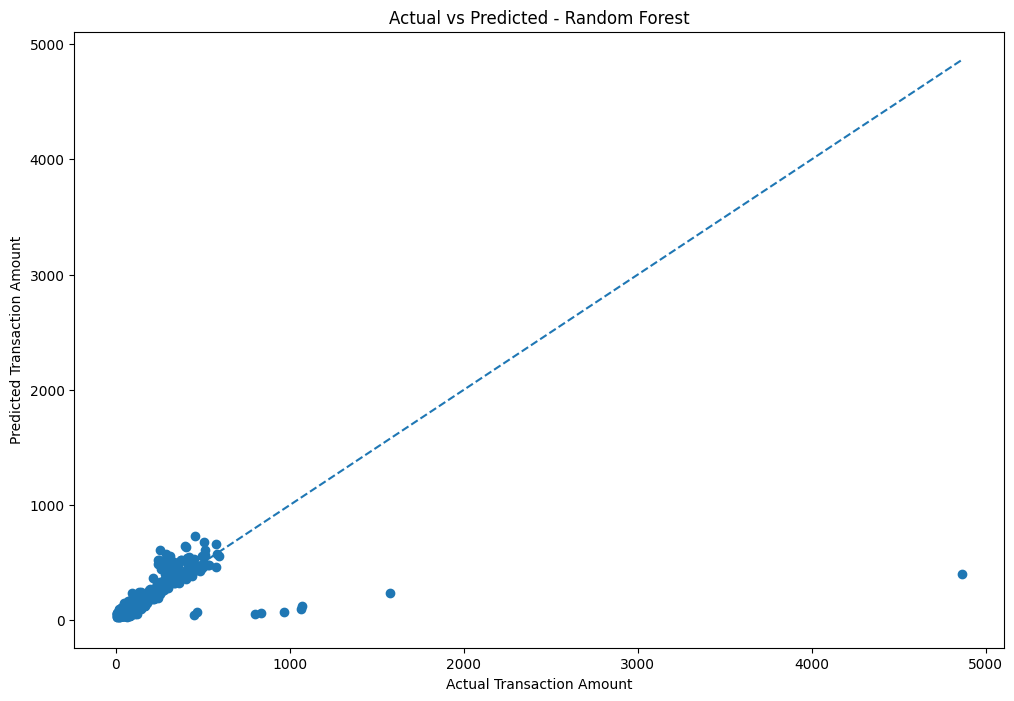

In [27]:
# Plot Actual vs Predicted values for the best model. How well does it capture high-spend outliers?

plt.figure(figsize=(12,8))
plt.scatter(y_test, random_forest_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],'--')
plt.xlabel('Actual Transaction Amount')
plt.ylabel('Predicted Transaction Amount')
plt.title('Actual vs Predicted - Random Forest')
plt.show()

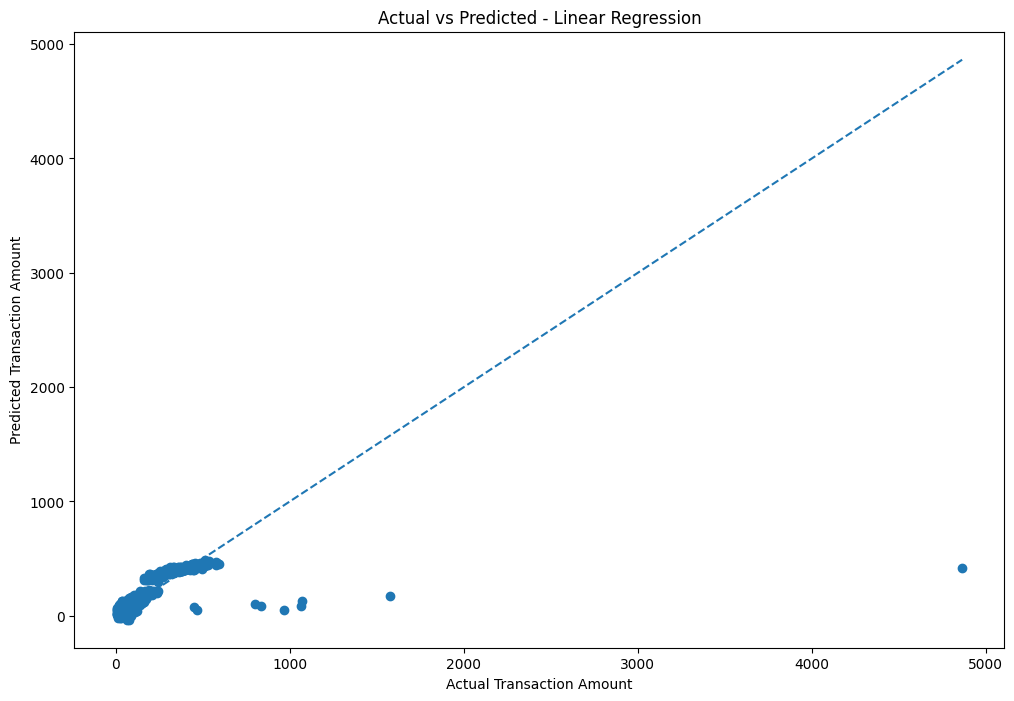

In [28]:
# for linear regression

plt.figure(figsize=(12,8))
plt.scatter(y_test, linear_reg_pred)
plt.plot([y_test.min(),y_test.max()],[y_test.min(), y_test.max()],"--")
plt.xlabel("Actual Transaction Amount")
plt.ylabel("Predicted Transaction Amount")
plt.title("Actual vs Predicted - Linear Regression")
plt.show()

In [29]:
# Create a comparison table: Model | Train R² | Test R² | MAE | RMSE. Recommend one model for deployment with justification.

# for training R sq we predict using the training data only
linear_reg_train_pred = linear_reg.predict(X_train)
linear_reg_train_r2 = r2_score(y_train, linear_reg_train_pred)

random_forest_train_pred = random_forest.predict(X_train)
random_forest_train_r2 = r2_score(y_train, random_forest_train_pred)

comparison_table = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'Train R2': [linear_reg_train_r2, random_forest_train_r2],
    'Test R2': [linear_reg_r2, random_forest_r2],
    'MAE': [linear_reg_mae, random_forest_mae],
    'RMSE': [linear_reg_rmse, random_forest_rmse]
})
print(comparison_table)

               Model  Train R2   Test R2        MAE        RMSE
0  Linear Regression  0.277094  0.321729  44.155481  166.317499
1      Random Forest  0.377682  0.315594  39.190982  167.067952


<p>As we can see, both the models have also same R square value and almost same RMSE value, it is becuase both of them are sensetive to outliers and we have some very extreme outliers. The noticable difference can be seen in MAE (Mean Absolute Error), in which Random Forest gives a lower error, this is because MAE is less dominated by extreme outliers, so it gives a more reliable measure of the model's performance. This is why we should go with Random Forest Regressor with this dataset.</p>

<p>RMSE = sq.root MSE (Mean Squared Error) = avg. of SSE (Sum of Squared Error) = sum of (Ypred - Yact)^2<br>
    MAE (Mean Absolute Error) =  avg. |Ypred - Yact|</p>